In [2]:
import pandas as pd

df = pd.read_csv('/content/Task_04_Accident_Dataset-1.csv')

print(df.head())

  Accident_ID        Date   Time Road_Surface_Conditions Weather_Conditions  \
0     ACC1001  2025-01-01  14:19                     Wet              Clear   
1     ACC1002  2025-01-02  11:36                     Dry        Strong Wind   
2     ACC1003  2025-01-03  15:03                     Dry           Fog/Mist   
3     ACC1004  2025-01-04  23:27                     Wet               Rain   
4     ACC1005  2025-01-05  18:43                     Wet              Clear   

  Accident_Severity  Contributing_Factor   Latitude  Longitude  
0             Fatal             Speeding  12.970576  77.639804  
1             Minor  Poor Road Condition  12.923816  77.601920  
2             Minor   Distracted Driving  12.917961  77.630418  
3           Serious  Poor Road Condition  12.946899  77.625000  
4             Minor              Weather  12.990671  77.593243  


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Accident_ID              500 non-null    object 
 1   Date                     500 non-null    object 
 2   Time                     500 non-null    object 
 3   Road_Surface_Conditions  500 non-null    object 
 4   Weather_Conditions       500 non-null    object 
 5   Accident_Severity        500 non-null    object 
 6   Contributing_Factor      500 non-null    object 
 7   Latitude                 500 non-null    float64
 8   Longitude                500 non-null    float64
dtypes: float64(2), object(7)
memory usage: 35.3+ KB
None


In [4]:
print(df.describe())

         Latitude   Longitude
count  500.000000  500.000000
mean    12.959800   77.613652
std      0.038724    0.023341
min     12.870729   77.550785
25%     12.928850   77.597100
50%     12.957756   77.613464
75%     12.986910   77.630291
max     13.045653   77.676783


In [5]:
print(df['Accident_Severity'].value_counts())

Accident_Severity
Minor      294
Serious    176
Fatal       30
Name: count, dtype: int64


In [6]:
# Convert Time into hour
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M').dt.hour

# Create time-of-day categories
def time_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['Time_of_Day'] = df['Hour'].apply(time_of_day)

# Count accidents by time of day
print(df['Time_of_Day'].value_counts())

Time_of_Day
Night        155
Morning      148
Afternoon    121
Evening       76
Name: count, dtype: int64


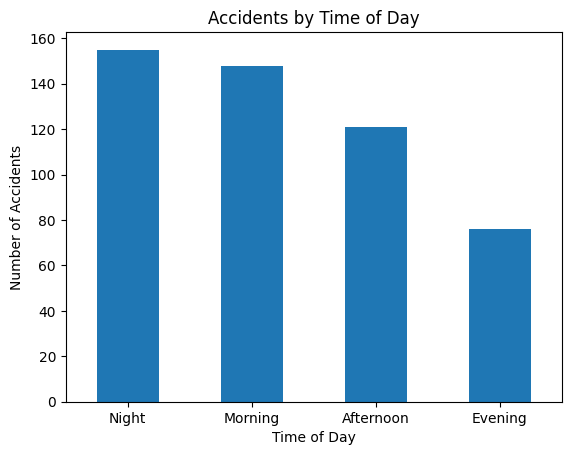

In [7]:
import matplotlib.pyplot as plt

df['Time_of_Day'].value_counts().plot(kind='bar')

plt.title('Accidents by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=0)
plt.show()

In [8]:
print(df['Road_Surface_Conditions'].value_counts())

Road_Surface_Conditions
Dry        287
Wet        131
Flooded     37
Icy         31
Snowy       14
Name: count, dtype: int64


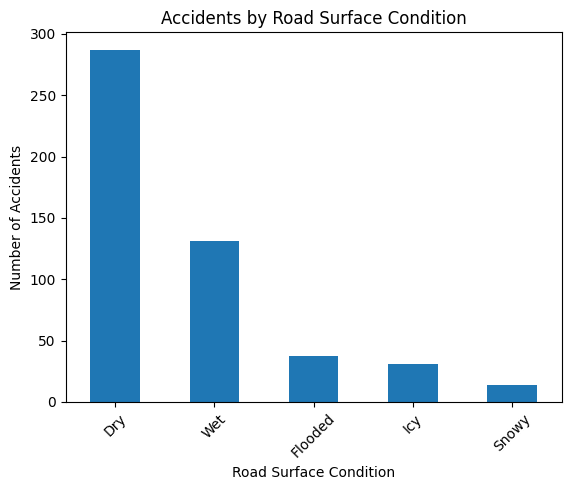

In [9]:
df['Road_Surface_Conditions'].value_counts().plot(kind='bar')

plt.title('Accidents by Road Surface Condition')
plt.xlabel('Road Surface Condition')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)
plt.show()

In [10]:
print(df['Weather_Conditions'].value_counts())

Weather_Conditions
Clear          233
Rain           113
Cloudy          76
Fog/Mist        48
Strong Wind     30
Name: count, dtype: int64


In [11]:
print(df['Contributing_Factor'].value_counts())

Contributing_Factor
Speeding               118
Distracted Driving     107
Poor Road Condition     73
Weather                 63
Drunk Driving           54
Fatigue                 45
Vehicle Failure         40
Name: count, dtype: int64


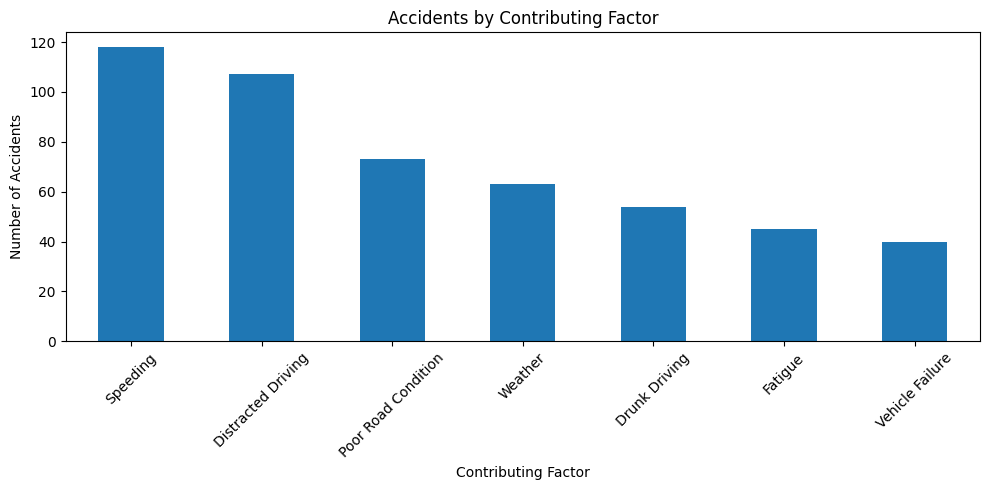

In [12]:
import matplotlib.pyplot as plt

factor_counts = df['Contributing_Factor'].value_counts()

plt.figure(figsize=(10,5))
factor_counts.plot(kind='bar')

plt.title('Accidents by Contributing Factor')
plt.xlabel('Contributing Factor')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
weather_severity = pd.crosstab(
    df['Weather_Conditions'],
    df['Accident_Severity']
)

print(weather_severity)

Accident_Severity   Fatal  Minor  Serious
Weather_Conditions                       
Clear                  10    136       87
Cloudy                  4     53       19
Fog/Mist                4     30       14
Rain                   12     57       44
Strong Wind             0     18       12


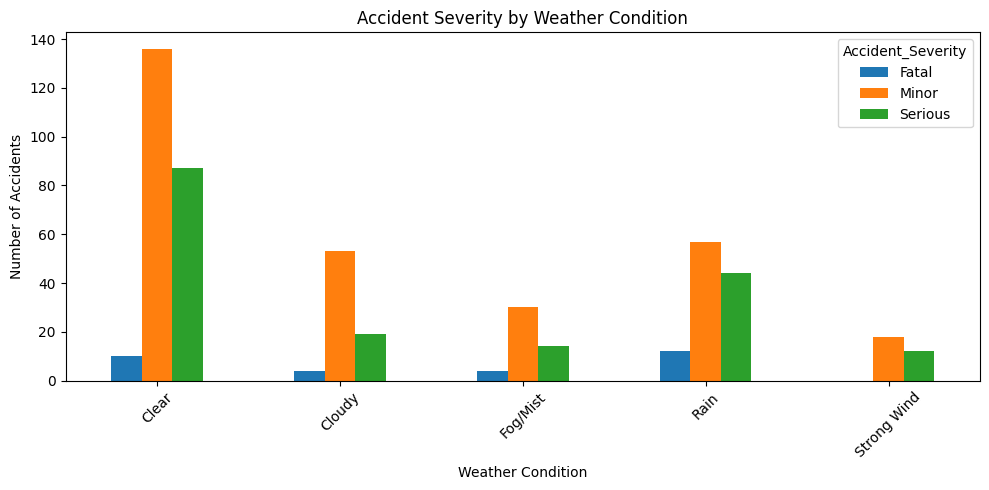

In [14]:
weather_severity.plot(kind='bar', figsize=(10,5))

plt.title('Accident Severity by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
road_severity = pd.crosstab(
    df['Road_Surface_Conditions'],
    df['Accident_Severity']
)

print(road_severity)

Accident_Severity        Fatal  Minor  Serious
Road_Surface_Conditions                       
Dry                         11    178       98
Flooded                      3     20       14
Icy                          2     16       13
Snowy                        1      7        6
Wet                         13     73       45


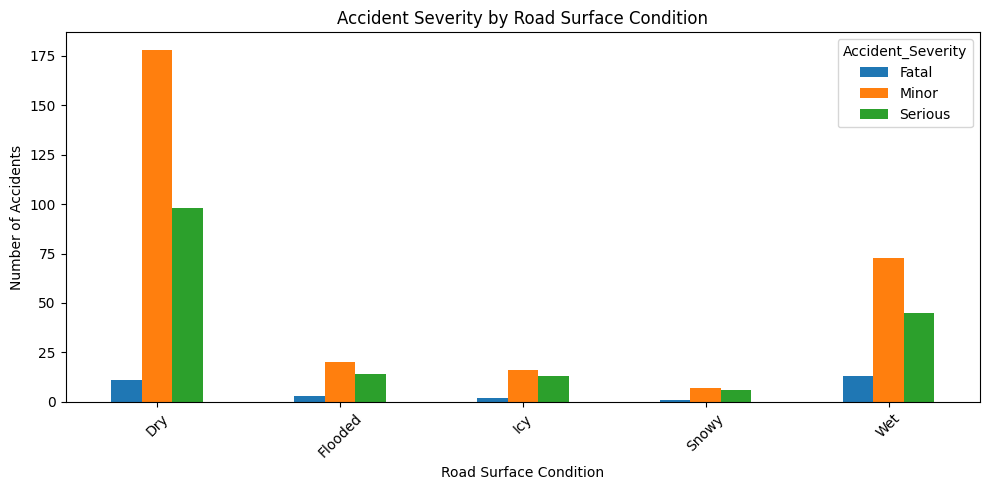

In [16]:
road_severity.plot(kind='bar', figsize=(10,5))

plt.title('Accident Severity by Road Surface Condition')
plt.xlabel('Road Surface Condition')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

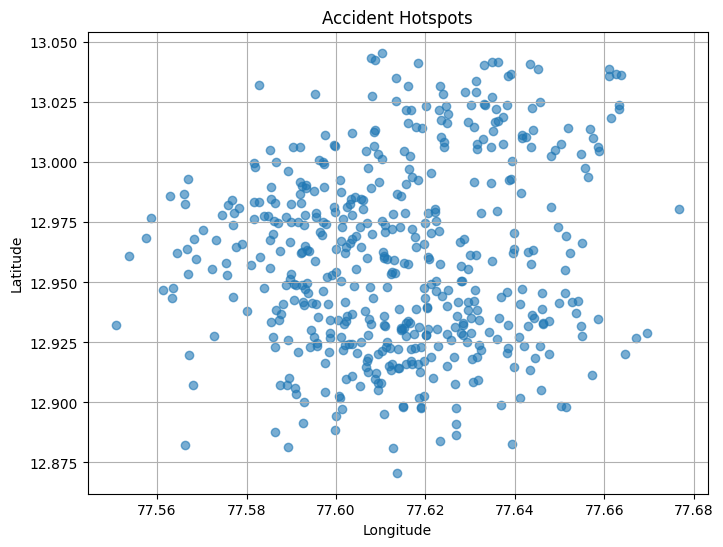

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['Longitude'],
    df['Latitude'],
    alpha=0.6
)

plt.title('Accident Hotspots')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.grid(True)
plt.show()

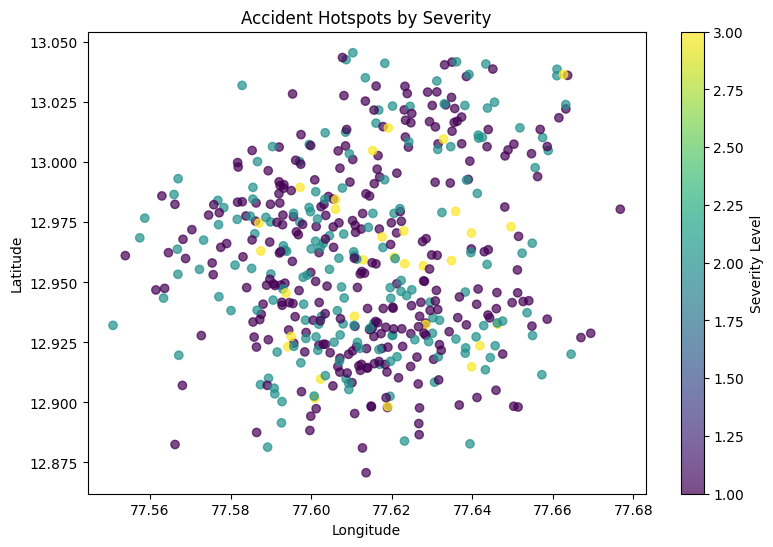

In [18]:
severity_map = {
    'Minor': 1,
    'Serious': 2,
    'Fatal': 3
}

df['Severity_Level'] = df['Accident_Severity'].map(severity_map)

plt.figure(figsize=(9,6))

plt.scatter(
    df['Longitude'],
    df['Latitude'],
    c=df['Severity_Level'],
    alpha=0.7
)

plt.title('Accident Hotspots by Severity')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.colorbar(label='Severity Level')

plt.show()

In [19]:
print("ACCIDENT DATA ANALYSIS SUMMARY")
print("--------------------------------")

print("Total accidents:", len(df))

print("\nMost common accident severity:")
print(df['Accident_Severity'].value_counts().idxmax())

print("\nMost common road condition:")
print(df['Road_Surface_Conditions'].value_counts().idxmax())

print("\nMost common weather condition:")
print(df['Weather_Conditions'].value_counts().idxmax())

print("\nMost common time of day:")
print(df['Time_of_Day'].value_counts().idxmax())

print("\nMost common contributing factor:")
print(df['Contributing_Factor'].value_counts().idxmax())

ACCIDENT DATA ANALYSIS SUMMARY
--------------------------------
Total accidents: 500

Most common accident severity:
Minor

Most common road condition:
Dry

Most common weather condition:
Clear

Most common time of day:
Night

Most common contributing factor:
Speeding


Conclusion

The traffic accident analysis shows that accidents occur more frequently at night compared with other times of the day. Dry road conditions and clear weather account for the highest number of recorded accidents, although accidents also occur under wet, flooded, icy, and adverse weather conditions. Minor accidents are the most common, followed by serious and fatal accidents. The contributing-factor analysis helps identify the major causes associated with accidents. The latitude and longitude visualization helps identify areas with a higher concentration of accidents, which can be considered potential accident hotspots. These findings can help authorities improve road safety measures, identify risky locations, and plan preventive actions.